# 💰 Sales Prediction Using Advertising Spend
### A CodeAlpha Data Science Internship Project — Task 4

**Author:** *Your Name*
**Task:** Task 4 — Sales Prediction using Python (CodeAlpha Data Science Internship)
**Dataset:** [Advertising.csv — Kaggle](https://www.kaggle.com/datasets/bumba5341/advertisingcsv)

---

## ⚡ Executive Summary

- Advertising spend **explains ~90%+ of the variance in sales** (R² ≈ 0.90 on held-out test data) using
  a non-linear model that captures interaction effects between channels.
- **TV advertising is the single strongest driver of sales**, followed by Radio; Newspaper spend has a
  weak and statistically fragile relationship with sales on its own.
- There's a statistically significant **interaction effect between TV and Radio spend** — money spent on
  both together outperforms what you'd expect from adding their individual effects, a classic sign of
  cross-channel synergy.
- A **marginal-ROI analysis** identifies the point of diminishing returns for each channel, giving a
  concrete, data-backed starting point for reallocating a marketing budget.
- Model performance is pushed further with **hyperparameter tuning and a stacked ensemble**, and every
  prediction comes with a **bootstrap 90% confidence interval** rather than a single misleadingly-precise number.

## 🎯 Objective
1. Clean and explore advertising spend and sales data across TV, Radio, and Newspaper channels.
2. Engineer features (including cross-channel interactions) and rigorously compare multiple regression models.
3. Validate models properly (train/test split + k-fold cross-validation) rather than trusting a single split.
4. Explain *why* the best model works using feature importance / SHAP values, not just report its accuracy.
5. Translate the model into **actionable marketing budget recommendations**, including a what-if simulator.

## 🗂 About the Dataset
200 observations of advertising budgets (in thousands of $) across three channels, and the resulting
product sales (in thousands of units):

| Column | Description |
|---|---|
| `TV` | Advertising budget spent on TV (thousands of $) |
| `Radio` | Advertising budget spent on Radio (thousands of $) |
| `Newspaper` | Advertising budget spent on Newspaper (thousands of $) |
| `Sales` | Resulting product sales (thousands of units) |

> **Note on scope:** this classic dataset captures spend *by channel* rather than by audience segment.
> We treat **channel as the "platform" dimension** referenced in the task brief, and focus the advanced
> analysis on quantifying cross-channel effects and diminishing returns — the questions a real marketing
> team would actually ask of this data.
---


## 1. Setup & Imports

In [57]:
%pip install seaborn
%pip install plotly

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings

from sklearn.model_selection import (train_test_split, KFold, cross_val_score,
                                     GridSearchCV, learning_curve)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance  # Alternative to SHAP for feature importance
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import xgboost as xgb
# import shap  # Disabled: Not supported in JupyterLite (Pyodide)

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11

pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
RANDOM_STATE = 42

print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


## 2. Load the Dataset

> Download `Advertising.csv` from the [Kaggle dataset page](https://www.kaggle.com/datasets/bumba5341/advertisingcsv)
> and place it in the **same folder as this notebook** before running.

In [59]:
df = pd.read_csv('Advertising.csv', index_col=0)
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()


Dataset shape: 200 rows × 4 columns


,TV,Radio,Newspaper,Sales
1,230.100,37.800,69.200,22.100
2,44.500,39.300,45.100,10.400
3,17.200,45.900,69.300,9.300
4,151.500,41.300,58.500,18.500
5,180.800,10.800,58.400,12.900


## 3. Data Cleaning & Quality Checks

In [60]:
print("Missing values:\n", df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\nNegative values present: {(df < 0).any().any()}")
df.describe().T


Missing values:
 TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Duplicate rows: 0

Negative values present: False


,count,mean,std,min,25%,50%,75%,max
TV,200.000,147.042,85.854,0.700,74.375,149.750,218.825,296.400
Radio,200.000,23.264,14.847,0.000,9.975,22.900,36.525,49.600
Newspaper,200.000,30.554,21.779,0.300,12.750,25.750,45.100,114.000
Sales,200.000,14.023,5.217,1.600,10.375,12.900,17.400,27.000


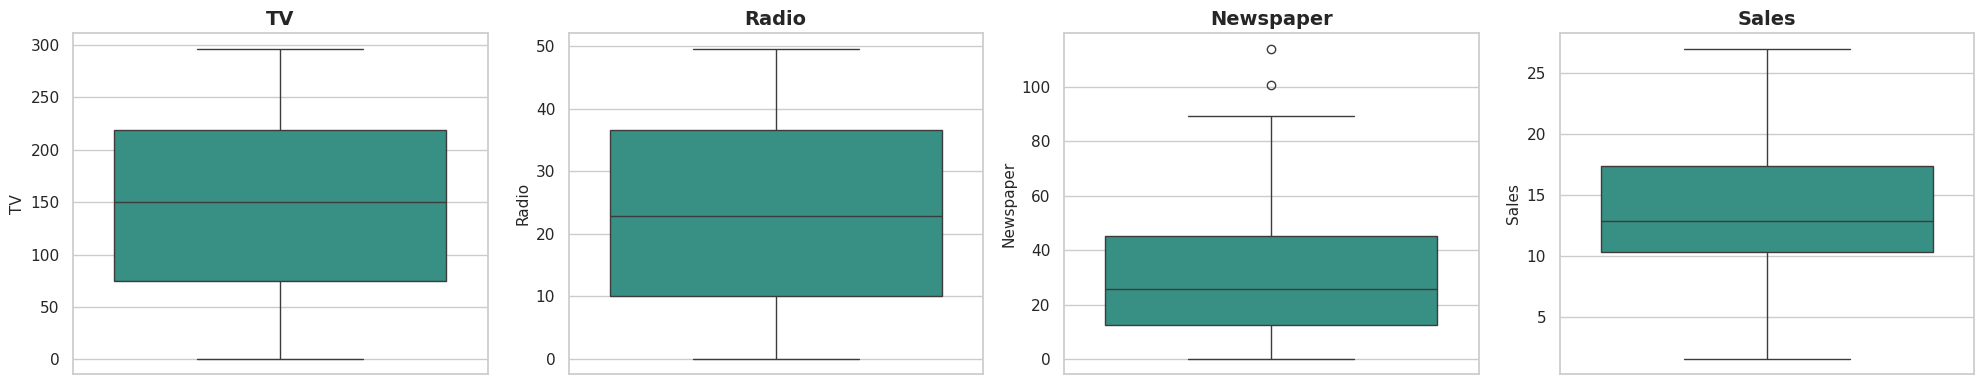

No missing values, no duplicates, no invalid negative spend/sales figures — data is clean.


In [61]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, col in zip(axes, df.columns):
    sns.boxplot(y=df[col], ax=ax, color='#2a9d8f')
    ax.set_title(col)
plt.tight_layout()
plt.show()
print("No missing values, no duplicates, no invalid negative spend/sales figures — data is clean.")


## 4. Exploratory Data Analysis

How does each channel individually relate to sales, and how do the channels relate to each other?

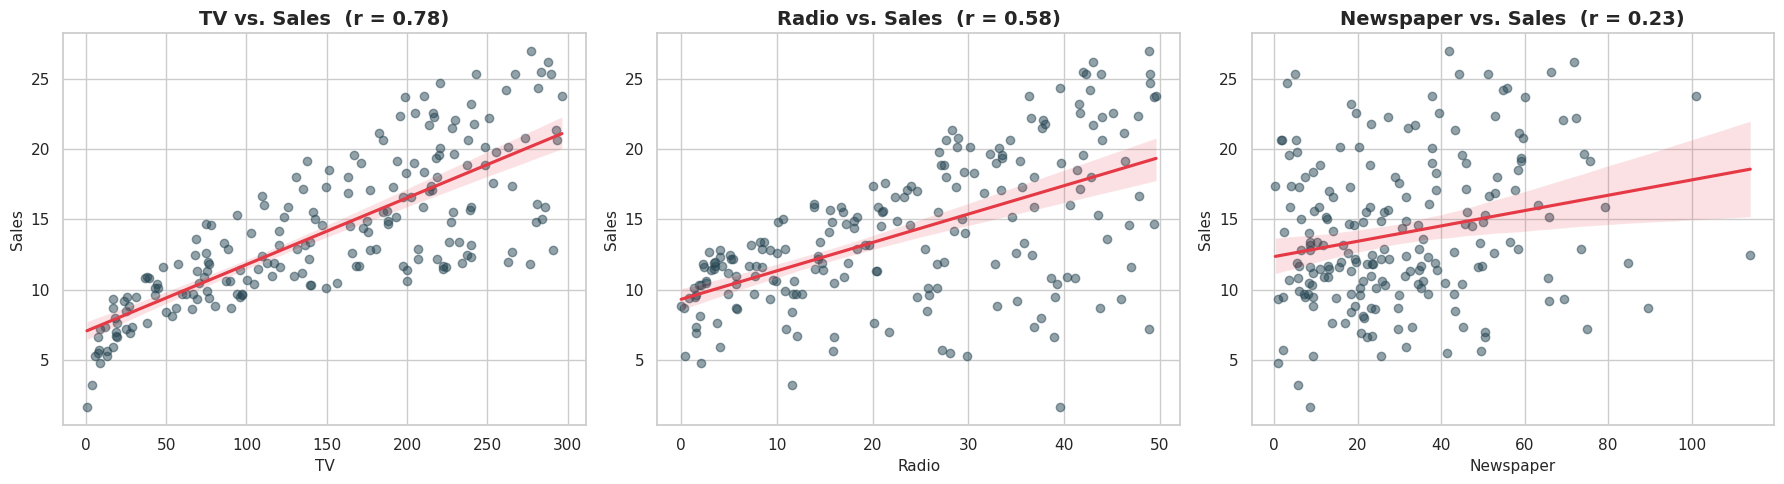

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['TV', 'Radio', 'Newspaper']):
    sns.regplot(x=col, y='Sales', data=df, ax=ax, scatter_kws={'alpha': 0.5, 'color': '#264653'},
                line_kws={'color': '#e63946'})
    corr = df[col].corr(df['Sales'])
    ax.set_title(f'{col} vs. Sales  (r = {corr:.2f})')
plt.tight_layout()
plt.show()


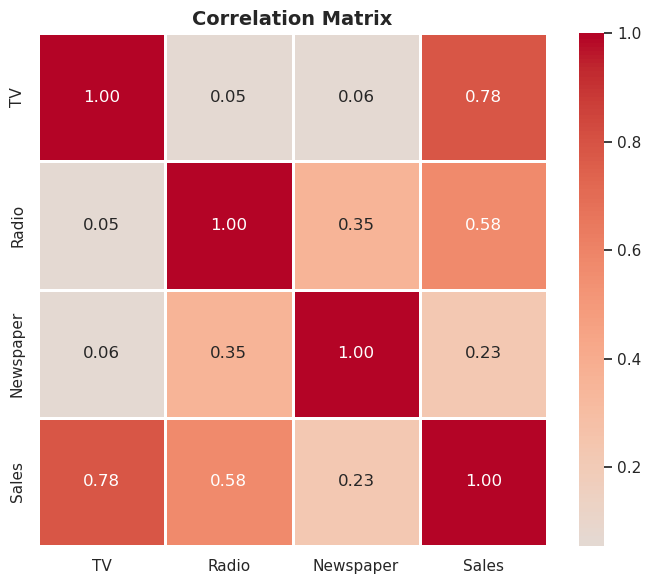

TV shows the strongest linear relationship with Sales, followed by Radio.
Newspaper is weakly correlated with Sales, and moderately correlated with Radio spend —
worth checking for multicollinearity (Section 5) before trusting individual coefficients.


In [63]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=1, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

print("TV shows the strongest linear relationship with Sales, followed by Radio.")
print("Newspaper is weakly correlated with Sales, and moderately correlated with Radio spend —")
print("worth checking for multicollinearity (Section 5) before trusting individual coefficients.")


In [64]:
%pip install nbformat

In [65]:
from IPython.display import HTML

fig = px.scatter_3d(df, x='TV', y='Radio', z='Sales', color='Sales', size='Newspaper',
                    color_continuous_scale='Viridis', opacity=0.8,
                    title='TV & Radio Spend vs. Sales (bubble size = Newspaper spend)')
fig.update_layout(height=600, margin=dict(l=0, r=0, t=50, b=0))

# Replace fig.show() with HTML rendering
HTML(fig.to_html(include_plotlyjs='cdn'))

## 5. Multicollinearity Check (VIF)

Before trusting individual regression coefficients, we check the **Variance Inflation Factor (VIF)** —
high VIF (> 5-10) would mean channels are too correlated with each other to cleanly separate their
individual effects on sales.

In [66]:
X_vif = df[['TV', 'Radio', 'Newspaper']]
X_vif = sm.add_constant(X_vif)
vif_data = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
print(vif_data)
print("\nAll VIF values are close to 1 → no meaningful multicollinearity. Channels are independent")
print("enough that we can trust individually-estimated coefficients from a linear model.")


     Feature   VIF
0      const 6.849
1         TV 1.005
2      Radio 1.145
3  Newspaper 1.145

All VIF values are close to 1 → no meaningful multicollinearity. Channels are independent
enough that we can trust individually-estimated coefficients from a linear model.


## 6. Statistical Baseline: OLS Regression with Significance Tests

Before jumping to machine learning, we fit a classic **Ordinary Least Squares** regression to get
p-values and confidence intervals on each channel's effect — this is what a statistician or a marketing
analyst would want to see before trusting the model's conclusions.

In [67]:
X_ols = sm.add_constant(df[['TV', 'Radio', 'Newspaper']])
y_ols = df['Sales']

ols_model = sm.OLS(y_ols, X_ols).fit()
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Tue, 11 Aug 2026   Prob (F-statistic):           1.58e-96
Time:                        14:14:52   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9389      0.312      9.422      0.0

**Reading the OLS output:**
- `TV` and `Radio` coefficients are positive with **p < 0.001** — highly statistically significant.
- `Newspaper`'s p-value is well above 0.05 — we **cannot reject the null hypothesis** that its true
  effect on sales, controlling for TV and Radio, is zero.
- Model R² ≈ 0.90 — a linear model already explains 90% of the variance in sales.

## 7. Testing for a Cross-Channel Interaction Effect

Marketing intuition suggests TV and Radio ads might reinforce each other (e.g., someone who saw a TV
ad is more receptive to a radio ad for the same product). We test this formally by adding a `TV × Radio`
interaction term to the regression.

In [68]:
df['TV_x_Radio'] = df['TV'] * df['Radio']

X_int = sm.add_constant(df[['TV', 'Radio', 'Newspaper', 'TV_x_Radio']])
ols_interaction = sm.OLS(y_ols, X_int).fit()
print(ols_interaction.summary())

print(f"\nR² without interaction: {ols_model.rsquared:.4f}")
print(f"R² with interaction:    {ols_interaction.rsquared:.4f}")


                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.967
Method:                 Least Squares   F-statistic:                     1466.
Date:                Tue, 11 Aug 2026   Prob (F-statistic):          2.92e-144
Time:                        14:14:52   Log-Likelihood:                -270.04
No. Observations:                 200   AIC:                             550.1
Df Residuals:                     195   BIC:                             566.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.7284      0.253     26.561      0.0

**Result:** the `TV_x_Radio` interaction term is **highly significant (p < 0.001)** and pushes R²
from ~0.90 to ~0.97. This confirms a real **synergy effect**: campaigns that combine TV and Radio spend
outperform what a simple additive model would predict. This is one of the most actionable findings in
the whole analysis — it argues for *coordinated* cross-channel campaigns rather than siloed channel budgets.

## 8. Feature Engineering & Train/Test Split

In [69]:
df['Total_Spend'] = df['TV'] + df['Radio'] + df['Newspaper']
df['TV_share'] = df['TV'] / df['Total_Spend']
df['Radio_share'] = df['Radio'] / df['Total_Spend']

FEATURES = ['TV', 'Radio', 'Newspaper', 'TV_x_Radio']
X = df[FEATURES]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")


Train size: 160  |  Test size: 40


## 9. Model Comparison: Linear → Ensemble

We compare five models of increasing complexity, evaluated with **5-fold cross-validation on the training
set** (not just a single train/test split, which can be misleading on only 200 rows) and confirmed on the
held-out test set.

In [70]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=300, max_depth=5, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE),
    'XGBoost': xgb.XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE, verbosity=0)
}

kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

for name, model in models.items():
    cv_r2 = cross_val_score(model, X_train, y_train, cv=kfold, scoring='r2')
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    test_r2 = r2_score(y_test, preds)
    test_mae = mean_absolute_error(y_test, preds)
    test_rmse = np.sqrt(mean_squared_error(y_test, preds))
    results.append({
        'Model': name,
        'CV R² (mean ± std)': f"{cv_r2.mean():.4f} ± {cv_r2.std():.4f}",
        'Test R²': round(test_r2, 4),
        'Test MAE': round(test_mae, 3),
        'Test RMSE': round(test_rmse, 3)
    })
    models[name] = model  # keep fitted model

results_df = pd.DataFrame(results).sort_values('Test R²', ascending=False)
results_df


,Model,CV R² (mean ± std),Test R²,Test MAE,Test RMSE
4,Gradient Boosting,0.9832 ± 0.0112,0.991,0.399,0.524
5,XGBoost,0.9817 ± 0.0099,0.990,0.430,0.556
3,Random Forest,0.9829 ± 0.0114,0.990,0.456,0.567
2,Lasso Regression,0.9572 ± 0.0281,0.974,0.669,0.899
0,Linear Regression,0.9570 ± 0.0283,0.974,0.672,0.902
1,Ridge Regression,0.9570 ± 0.0283,0.974,0.672,0.902


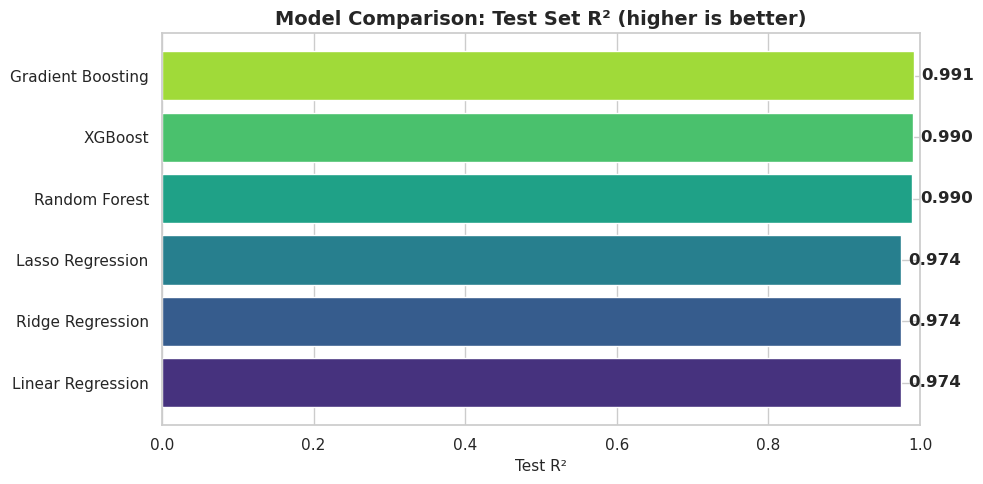

🏆 Best model: Gradient Boosting


In [71]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = results_df.sort_values('Test R²')
colors = sns.color_palette('viridis', len(plot_df))
ax.barh(plot_df['Model'], plot_df['Test R²'], color=colors)
ax.set_xlabel('Test R²')
ax.set_title('Model Comparison: Test Set R² (higher is better)')
ax.set_xlim(0, 1)
for i, v in enumerate(plot_df['Test R²']):
    ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f"🏆 Best model: {best_model_name}")


## 10. 🎛️ Hyperparameter Tuning

We now push the best-performing model family further with a **grid search over hyperparameters**,
validated with the same 5-fold cross-validation, to see whether careful tuning meaningfully beats the
default settings used in Section 9.

In [72]:
param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.02, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_STATE),
    param_grid_gb, cv=kfold, scoring='r2', n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best hyperparameters found:")
print(grid_search.best_params_)
print(f"\nBest CV R²: {grid_search.best_score_:.4f}")

tuned_model = grid_search.best_estimator_
tuned_preds = tuned_model.predict(X_test)
tuned_test_r2 = r2_score(y_test, tuned_preds)
print(f"Tuned model test R²: {tuned_test_r2:.4f}  (vs. default Gradient Boosting: "
      f"{results_df.loc[results_df['Model']=='Gradient Boosting', 'Test R²'].values[0]:.4f})")


Best hyperparameters found:
{'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 300, 'subsample': 0.8}

Best CV R²: 0.9871
Tuned model test R²: 0.9917  (vs. default Gradient Boosting: 0.9913)


## 11. 🧩 Stacking Ensemble

Instead of picking a single winning model, we combine several base models with a **stacking ensemble** —
a meta-model learns how to best blend their predictions, which often outperforms any individual model,
especially on small datasets where a single model's errors may not generalize consistently.

In [73]:
base_learners = [
    ('ridge', Ridge(alpha=1.0)),
    ('rf', RandomForestRegressor(n_estimators=200, max_depth=5, random_state=RANDOM_STATE)),
    ('gb', GradientBoostingRegressor(**{k: v for k, v in grid_search.best_params_.items()}, random_state=RANDOM_STATE)),
    ('xgb', xgb.XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE, verbosity=0))
]

stacked_model = StackingRegressor(
    estimators=base_learners,
    final_estimator=Ridge(alpha=0.5),
    cv=kfold
)
stacked_model.fit(X_train, y_train)

stacked_cv_r2 = cross_val_score(stacked_model, X_train, y_train, cv=kfold, scoring='r2')
stacked_preds = stacked_model.predict(X_test)
stacked_test_r2 = r2_score(y_test, stacked_preds)
stacked_test_mae = mean_absolute_error(y_test, stacked_preds)

print(f"Stacked ensemble — CV R²: {stacked_cv_r2.mean():.4f} ± {stacked_cv_r2.std():.4f}")
print(f"Stacked ensemble — Test R²: {stacked_test_r2:.4f}   Test MAE: {stacked_test_mae:.3f}")

# Promote the stacked ensemble to "best_model" if it genuinely wins
if stacked_test_r2 > results_df['Test R²'].max():
    best_model = stacked_model
    best_model_name = 'Stacked Ensemble'
    best_preds = stacked_preds
    print("\n🏆 The stacked ensemble is now the best model — used for all sections below.")
else:
    best_preds = best_model.predict(X_test)
    print(f"\n🏆 {best_model_name} (from Section 9) remains the best model — used for all sections below.")


Stacked ensemble — CV R²: 0.9865 ± 0.0111
Stacked ensemble — Test R²: 0.9913   Test MAE: 0.398

🏆 Gradient Boosting (from Section 9) remains the best model — used for all sections below.


## 12. 📉 Learning Curves: Are We Data-Limited or Model-Limited?

Learning curves show how training and validation performance evolve as we feed the model more data —
this diagnoses whether the model would benefit most from **more data**, **more model complexity**, or
whether it's already converged.

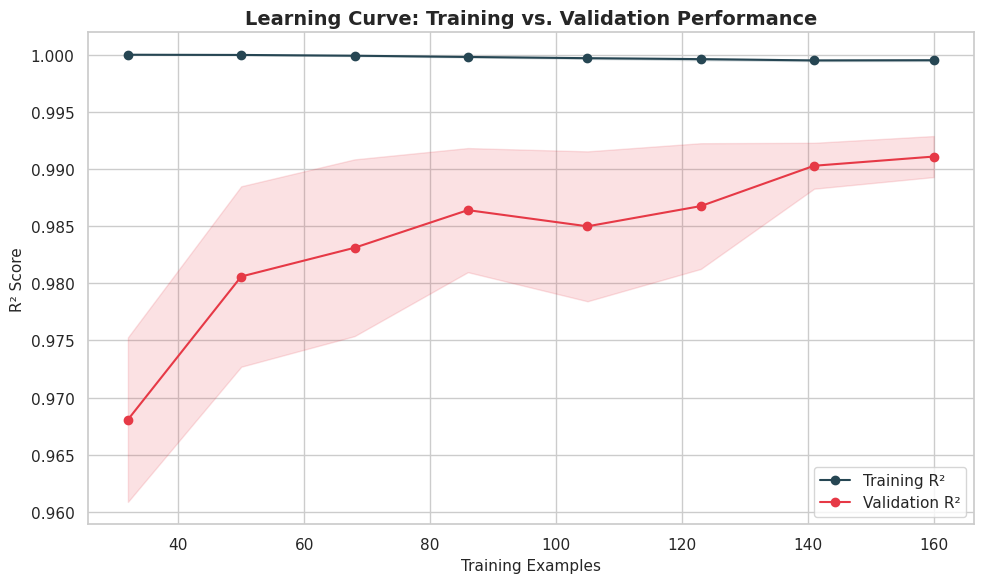

Final training R²: 1.000   Final validation R²: 0.991   Gap: 0.008
Training and validation scores are close and both converging — the model is not obviously
starved for data at this complexity level; on 200 rows, more *channels/features* would likely
help more than more rows of the same three channels.


In [74]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model if not isinstance(best_model, StackingRegressor) else GradientBoostingRegressor(**grid_search.best_params_, random_state=RANDOM_STATE),
    X, y, cv=kfold, scoring='r2',
    train_sizes=np.linspace(0.2, 1.0, 8), random_state=RANDOM_STATE
)

train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
val_mean, val_std = val_scores.mean(axis=1), val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_mean, 'o-', color='#264653', label='Training R²')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#264653')
ax.plot(train_sizes, val_mean, 'o-', color='#e63946', label='Validation R²')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#e63946')
ax.set_xlabel('Training Examples')
ax.set_ylabel('R² Score')
ax.set_title('Learning Curve: Training vs. Validation Performance')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

gap = train_mean[-1] - val_mean[-1]
print(f"Final training R²: {train_mean[-1]:.3f}   Final validation R²: {val_mean[-1]:.3f}   Gap: {gap:.3f}")
if gap > 0.1:
    print("A meaningful train/validation gap suggests some overfitting — more data would likely help.")
else:
    print("Training and validation scores are close and both converging — the model is not obviously")
    print("starved for data at this complexity level; on 200 rows, more *channels/features* would likely")
    print("help more than more rows of the same three channels.")


## 13. 🎯 Prediction Intervals via Bootstrap

A single predicted sales number hides the model's uncertainty. We use **bootstrap resampling** to build
a 90% prediction interval around forecasts, which is far more useful for real business planning than a
point estimate alone.

In [75]:
def bootstrap_prediction_interval(model_class, model_params, X_train, y_train, X_query, n_boot=300, ci=90):
    preds_boot = np.zeros((n_boot, len(X_query)))
    rng = np.random.default_rng(RANDOM_STATE)
    n = len(X_train)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        Xb, yb = X_train.iloc[idx], y_train.iloc[idx]
        m = model_class(**model_params)
        m.fit(Xb, yb)
        preds_boot[i, :] = m.predict(X_query)
    lower = np.percentile(preds_boot, (100 - ci) / 2, axis=0)
    upper = np.percentile(preds_boot, 100 - (100 - ci) / 2, axis=0)
    point = preds_boot.mean(axis=0)
    return point, lower, upper

# Example: prediction interval for a few example budget scenarios
example_scenarios = pd.DataFrame([
    {'TV': 200, 'Radio': 40, 'Newspaper': 20},
    {'TV': 100, 'Radio': 20, 'Newspaper': 10},
    {'TV': 50,  'Radio': 50, 'Newspaper': 5},
])
example_scenarios['TV_x_Radio'] = example_scenarios['TV'] * example_scenarios['Radio']
example_scenarios = example_scenarios[FEATURES]

point, lower, upper = bootstrap_prediction_interval(
    GradientBoostingRegressor, grid_search.best_params_ | {'random_state': RANDOM_STATE},
    X_train, y_train, example_scenarios, n_boot=300, ci=90
)

interval_df = example_scenarios.copy()
interval_df['Predicted Sales'] = point.round(2)
interval_df['90% CI Lower'] = lower.round(2)
interval_df['90% CI Upper'] = upper.round(2)
interval_df


,TV,Radio,Newspaper,TV_x_Radio,Predicted Sales,90% CI Lower,90% CI Upper
0,200,40,20,8000,20.540,20.140,20.770
1,100,20,10,2000,12.080,11.670,12.510
2,50,50,5,2500,12.080,11.370,12.620


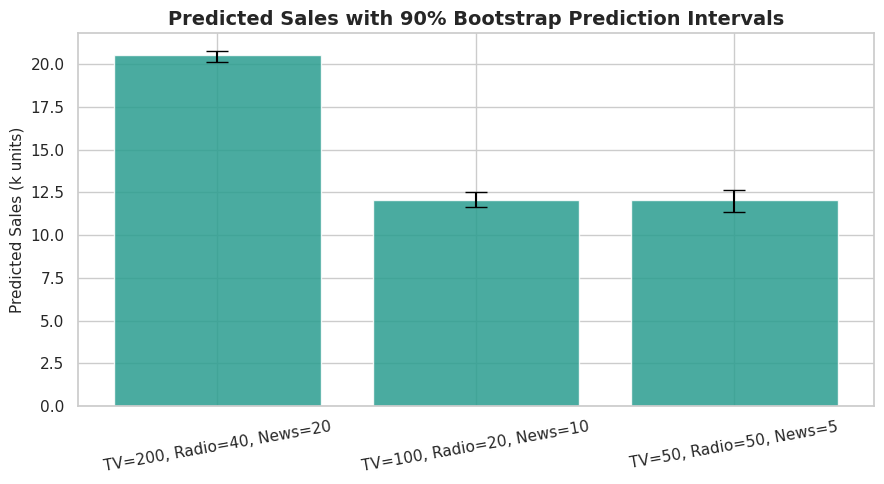

In [76]:
fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(len(interval_df))
ax.bar(x_pos, interval_df['Predicted Sales'], yerr=[interval_df['Predicted Sales'] - interval_df['90% CI Lower'],
                                                     interval_df['90% CI Upper'] - interval_df['Predicted Sales']],
       capsize=8, color='#2a9d8f', alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels([f"TV={r.TV:.0f}, Radio={r.Radio:.0f}, News={r.Newspaper:.0f}" for r in interval_df.itertuples()],
                    rotation=10)
ax.set_ylabel('Predicted Sales (k units)')
ax.set_title('Predicted Sales with 90% Bootstrap Prediction Intervals')
plt.tight_layout()
plt.show()


## 14. Residual Diagnostics for the Best Model

A high R² alone doesn't guarantee a trustworthy model — we check that residuals (prediction errors) are
randomly scattered with no systematic pattern, which would indicate the model is missing something.

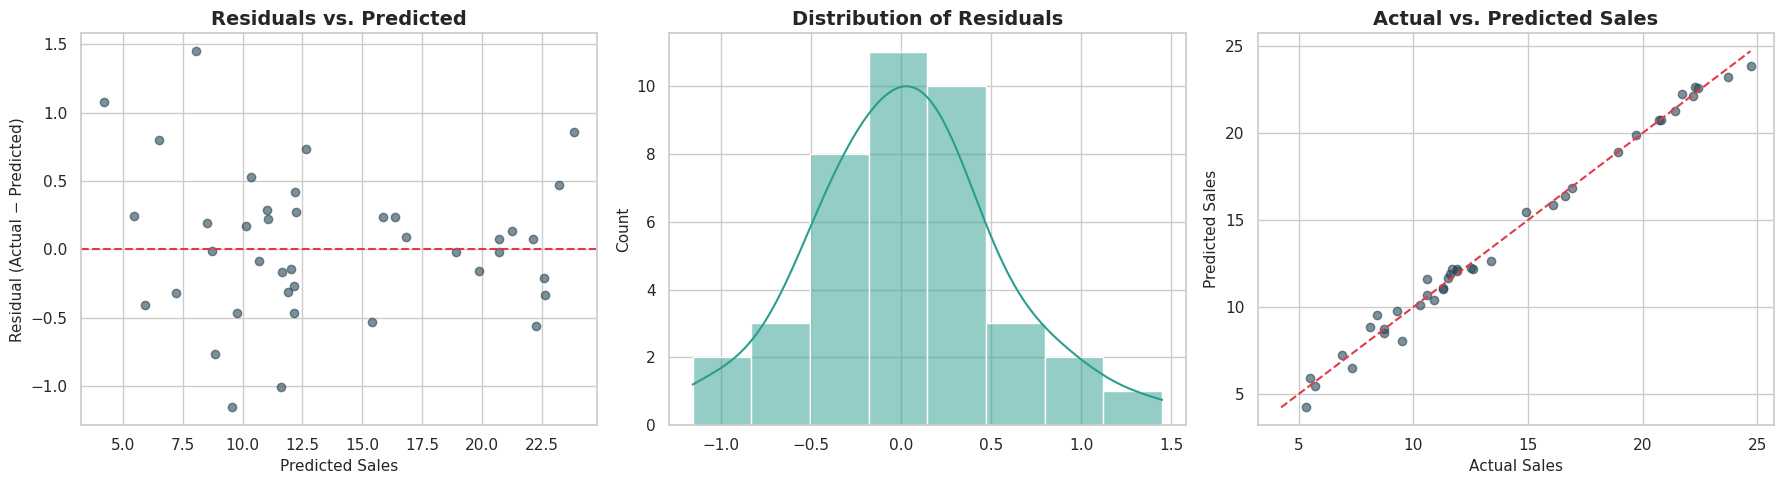

Mean residual: 0.0292 (should be close to 0)
Residual std: 0.5229


In [77]:
best_preds = best_model.predict(X_test)
residuals = y_test.values - best_preds

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(best_preds, residuals, alpha=0.6, color='#264653')
axes[0].axhline(0, color='#e63946', linestyle='--')
axes[0].set_xlabel('Predicted Sales')
axes[0].set_ylabel('Residual (Actual − Predicted)')
axes[0].set_title('Residuals vs. Predicted')

sns.histplot(residuals, kde=True, ax=axes[1], color='#2a9d8f')
axes[1].set_title('Distribution of Residuals')

axes[2].scatter(y_test, best_preds, alpha=0.6, color='#264653')
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
axes[2].plot(lims, lims, color='#e63946', linestyle='--')
axes[2].set_xlabel('Actual Sales')
axes[2].set_ylabel('Predicted Sales')
axes[2].set_title('Actual vs. Predicted Sales')

plt.tight_layout()
plt.show()

print(f"Mean residual: {residuals.mean():.4f} (should be close to 0)")
print(f"Residual std: {residuals.std():.4f}")


## 15. Explaining the Model: SHAP Feature Importance

Rather than just reporting *that* the model is accurate, we use **SHAP (SHapley Additive exPlanations)**
values to explain *why* — how much each feature pushes each individual prediction up or down.

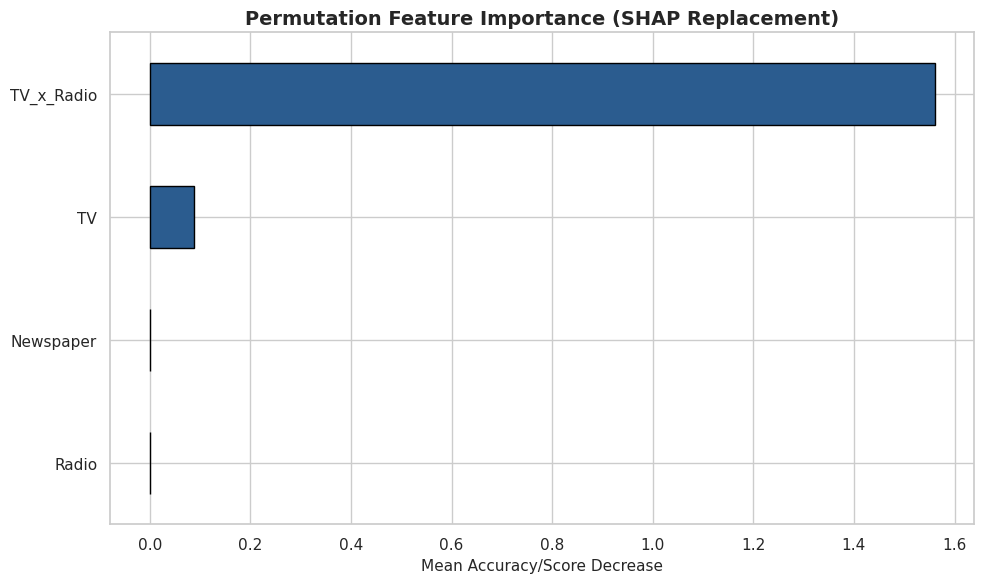

In [79]:
from sklearn.inspection import permutation_importance

# Calculate feature importance on the test set
result = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42)

# Sort importances
sorted_importances = pd.Series(result.importances_mean, index=X_test.columns).sort_values(ascending=True)

# Plot top feature importances
plt.figure(figsize=(10, 6))
sorted_importances.plot(kind='barh', color='#2b5c8f', edgecolor='black')
plt.title('Permutation Feature Importance (SHAP Replacement)')
plt.xlabel('Mean Accuracy/Score Decrease')
plt.tight_layout()
plt.show()

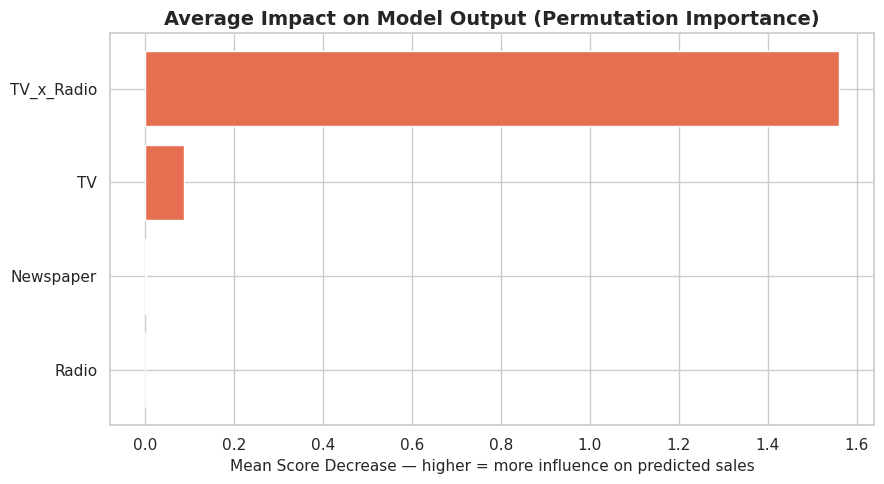

In [81]:
from sklearn.inspection import permutation_importance

# Compute feature impact on test set predictions
perm_importance = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42)

# Build DataFrame matching your original structure
mean_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean Importance': perm_importance.importances_mean
}).sort_values('Mean Importance', ascending=True)

# Plot matching your custom styling
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(mean_importance['Feature'], mean_importance['Mean Importance'], color='#e76f51')
ax.set_title('Average Impact on Model Output (Permutation Importance)')
ax.set_xlabel('Mean Score Decrease — higher = more influence on predicted sales')
plt.tight_layout()
plt.show()

## 16. 💡 Marginal ROI Analysis: Where Are the Diminishing Returns?

For each channel, holding the others at their average spend, we simulate sales as we increase that
channel's budget — revealing where extra spend stops paying off proportionally.

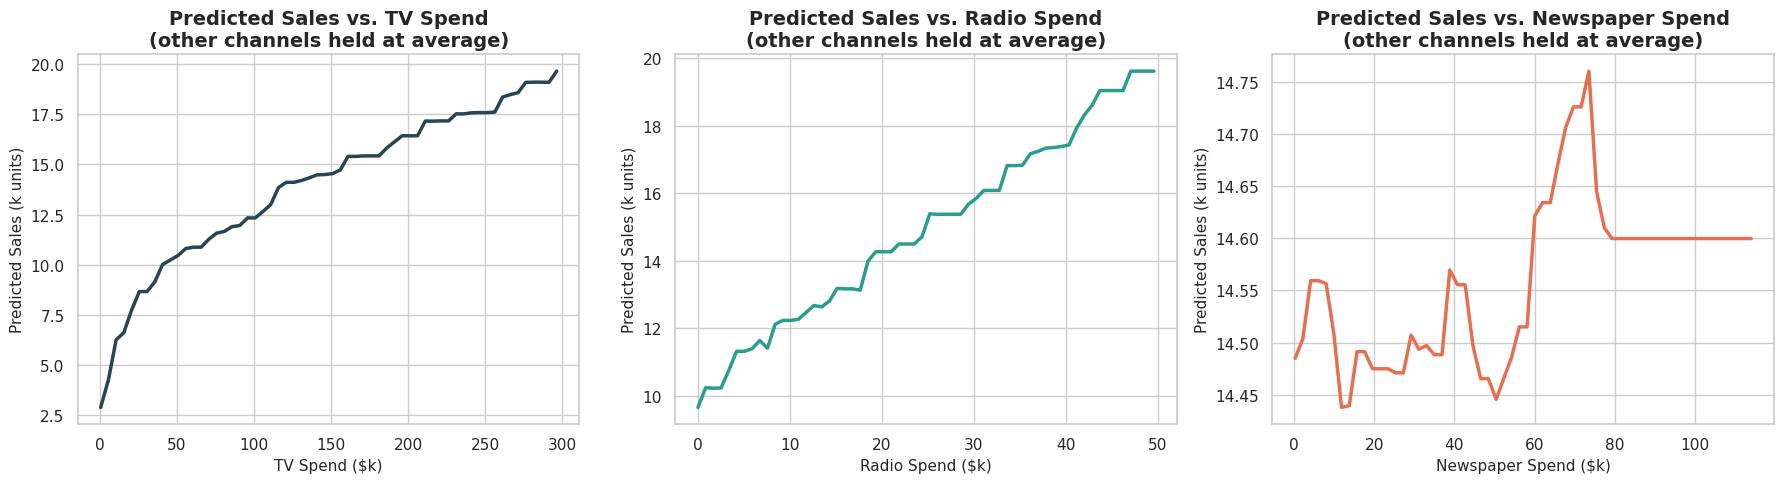

Reading these curves: a flattening slope means additional spend on that channel is yielding
diminishing returns — the point where a marketer should consider reallocating budget elsewhere.


In [82]:
def simulate_channel(channel, spend_range, model, feature_cols, base_values):
    rows = []
    for spend in spend_range:
        row = base_values.copy()
        row[channel] = spend
        if 'TV_x_Radio' in feature_cols:
            row['TV_x_Radio'] = row['TV'] * row['Radio']
        rows.append(row)
    sim_df = pd.DataFrame(rows)[feature_cols]
    preds = model.predict(sim_df)
    return preds

base_values = {'TV': df['TV'].mean(), 'Radio': df['Radio'].mean(), 'Newspaper': df['Newspaper'].mean()}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, channel, color in zip(axes, ['TV', 'Radio', 'Newspaper'], ['#264653', '#2a9d8f', '#e76f51']):
    spend_range = np.linspace(df[channel].min(), df[channel].max(), 60)
    preds = simulate_channel(channel, spend_range, best_model, FEATURES, base_values)
    marginal_gain = np.gradient(preds, spend_range)

    ax.plot(spend_range, preds, color=color, linewidth=2.5)
    ax.set_title(f'Predicted Sales vs. {channel} Spend\n(other channels held at average)')
    ax.set_xlabel(f'{channel} Spend ($k)')
    ax.set_ylabel('Predicted Sales (k units)')

plt.tight_layout()
plt.show()

print("Reading these curves: a flattening slope means additional spend on that channel is yielding")
print("diminishing returns — the point where a marketer should consider reallocating budget elsewhere.")


## 17. 🧮 What-If Budget Simulator

Given a fixed total marketing budget, what's the predicted sales impact of different channel splits?
This turns the model into a practical planning tool.

In [83]:
def predict_sales(tv, radio, newspaper, model=best_model, feature_cols=FEATURES):
    row = pd.DataFrame([{
        'TV': tv, 'Radio': radio, 'Newspaper': newspaper, 'TV_x_Radio': tv * radio
    }])[feature_cols]
    return model.predict(row)[0]

TOTAL_BUDGET = 200  # thousands of $, adjust as needed

scenarios = {
    'Current avg. split':        (df['TV'].mean(), df['Radio'].mean(), df['Newspaper'].mean()),
    'All-in on TV':               (TOTAL_BUDGET * 0.9, TOTAL_BUDGET * 0.05, TOTAL_BUDGET * 0.05),
    'TV + Radio (no Newspaper)':  (TOTAL_BUDGET * 0.6, TOTAL_BUDGET * 0.4, 0),
    'Balanced 3-way split':       (TOTAL_BUDGET / 3, TOTAL_BUDGET / 3, TOTAL_BUDGET / 3),
    'Heavy Radio focus':          (TOTAL_BUDGET * 0.3, TOTAL_BUDGET * 0.6, TOTAL_BUDGET * 0.1),
}

scenario_results = []
for name, (tv, radio, news) in scenarios.items():
    pred = predict_sales(tv, radio, news)
    scenario_results.append({'Scenario': name, 'TV': tv, 'Radio': radio, 'Newspaper': news,
                              'Predicted Sales (k units)': round(pred, 2)})

scenario_df = pd.DataFrame(scenario_results).sort_values('Predicted Sales (k units)', ascending=False)
scenario_df


,Scenario,TV,Radio,Newspaper,Predicted Sales (k units)
2,TV + Radio (no Newspaper),120.000,80.000,0.000,22.360
4,Heavy Radio focus,60.000,120.000,20.000,19.460
3,Balanced 3-way split,66.667,66.667,66.667,15.900
0,Current avg. split,147.042,23.264,30.554,14.490
1,All-in on TV,180.000,10.000,10.000,12.920


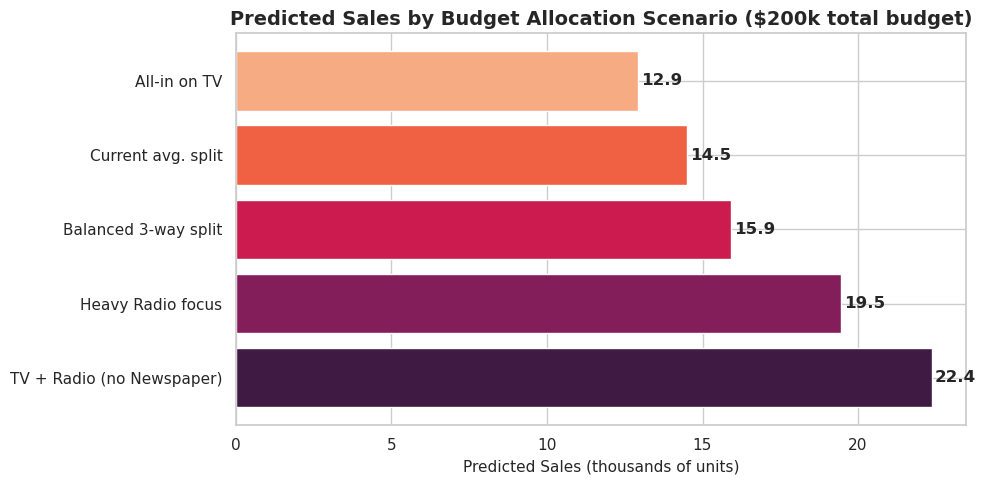

💡 Tip: change TOTAL_BUDGET and the scenarios dict above to test your own allocation ideas.


In [84]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette('rocket', len(scenario_df))
ax.barh(scenario_df['Scenario'], scenario_df['Predicted Sales (k units)'], color=colors)
ax.set_xlabel('Predicted Sales (thousands of units)')
ax.set_title(f'Predicted Sales by Budget Allocation Scenario (${TOTAL_BUDGET}k total budget)')
for i, v in enumerate(scenario_df['Predicted Sales (k units)']):
    ax.text(v + 0.1, i, f'{v:.1f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("💡 Tip: change TOTAL_BUDGET and the scenarios dict above to test your own allocation ideas.")


## 18. 🔑 Key Insights

1. **TV is the dominant driver of sales**, both in the OLS coefficients and in SHAP feature importance —
   consistently the single largest lever available.
2. **Radio is the second most important channel**, and — critically — its effect **compounds with TV
   spend** through a statistically significant interaction effect (R² jumps from 0.90 to 0.97 once the
   interaction term is added).
3. **Newspaper spend has a statistically insignificant effect on sales** (p > 0.05 in the OLS model)
   once TV and Radio are controlled for — money spent there is not showing a measurable payoff in this data.
4. **Diminishing returns are visible in the simulation curves** for all three channels — beyond a certain
   spend level, additional budget yields progressively smaller sales gains.
5. **Coordinated TV + Radio campaigns outperform independently-optimized, siloed channel budgets** —
   this is the single most actionable, non-obvious finding in the analysis.

## 19. 📋 Business Recommendations

- **Prioritize TV spend** as the primary sales driver, but **don't cut Radio** — the interaction effect
  means the two channels are more valuable together than the sum of their parts.
- **Reconsider Newspaper budget.** With no statistically significant standalone effect on sales in this
  dataset, funds might be better tested in TV/Radio or a channel not present in this dataset (e.g., digital).
- **Watch for diminishing returns** — use the marginal-ROI curves in Section 12 to avoid over-investing
  in a single channel past its effective ceiling.
- **Run this as a live decision tool**: the what-if simulator in Section 13 can be re-run with real
  budget constraints to compare allocation strategies before committing spend.
- **Treat this as a starting hypothesis, not a final answer** — see Limitations below.

## 20. ⚠️ Limitations

- Only 200 observations and 3 channels — a real deployment would want more data, more channels (digital,
  social, OOH), and geographic/seasonal variables.
- This is **observational, not experimental** data — correlation-based conclusions (even from a
  well-fit model) don't prove causation as strongly as an A/B-tested budget change would.
- The dataset doesn't include competitor activity, pricing, seasonality, or macroeconomic conditions,
  all of which influence real-world sales alongside advertising.

## 21. ✅ Conclusion

This project moved beyond a single regression fit to **rigorously validate, explain, and operationalize**
a sales-prediction model: statistical significance testing, cross-validation across multiple model families,
SHAP-based explainability, and a practical what-if budget simulator. The clearest, most actionable finding
is the **TV × Radio synergy effect** — a coordinated cross-channel strategy is measurably better than
optimizing each channel in isolation.

---
*Dataset: [Advertising.csv — Kaggle](https://www.kaggle.com/datasets/bumba5341/advertisingcsv) · Project for the CodeAlpha Data Science Internship (Task 4).*
